In [3]:
# All the imports

import numpy as np
np.set_printoptions(legacy='1.25')
import math
from skfem import MeshQuad, MeshTri, Basis, asm, condense
from skfem.element import ElementQuad1, ElementTriP1
from skfem.models.poisson import laplace
from skfem.helpers import dot, grad
from skfem import BilinearForm, LinearForm
from skfem.utils import solve
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot
from scipy.sparse.linalg import eigsh, ArpackNoConvergence
import pickle
from scipy.sparse.linalg import splu, LinearOperator, eigsh
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
from mpl_toolkits.mplot3d import Axes3D
import itertools
import os

from eigenvector_convergence.eigenvector_helpers import (
    Absorption_checkerboard, D_checkerboard, D_random, Fission_checkerboard,
    _tensor_product_basis, a_checkerboard, a_random, b_checkerboard,
    eigvecs_at_level, eigvecs_at_level_defined, fix_sign,
    plot_bilinear_hat_solution, load_and_collapse_c5g7_full_core
)

Build the fixed 128 x 128 C5G7 material grid and compare coarse-mesh eigenvectors with a fine reference eigenvector.


In [4]:
def get_coarse_overlaps(
    flux,
    min_r,
    max_refinement,
    ref_refinement,
    assembly_type="uo2",
    assembly_layout=None,
):
    """Compare coarse C5G7 eigenvectors with a fine reference solution.

    ``flux`` is the seven-group spectrum used to collapse every C5G7
    material.  The same resulting 128 x 128 material arrays are supplied
    to every eigenproblem, so only the finite-element mesh changes.
    """
    if min_r > max_refinement:
        raise ValueError("min_r must not exceed max_refinement.")
    if ref_refinement < max_refinement:
        raise ValueError("ref_refinement must be at least max_refinement.")

    total_mat, sigma_a_mat, nu_sigma_f_mat = load_and_collapse_c5g7_full_core("eigenvector_convergence")
    D_mat = 1 / (3 * total_mat)  # Assuming D_mat corresponds to total_mat
    mat_r = 7  # 2**7 cells per axis matches the 128 x 128 material arrays.
    data = {
        "levels": [],
        "lambda1": [],
        "u_full": [],
        "interpolated_coarse_solutions": [],
        "chi": [],
    }

    for r in range(min_r, max_refinement + 1):
        lambda1, u_full = eigvecs_at_level_defined(
            mat_r=mat_r,
            r=r,
            D_mat=D_mat,
            sigma_a_mat=sigma_a_mat,
            nu_sigma_f_mat=nu_sigma_f_mat,
            do_plot=False,
        )
        data["levels"].append(r)
        data["lambda1"].append(float(lambda1))
        data["u_full"].append(fix_sign(u_full))
        print(
            f"level: {r}, lambda1: {lambda1}, full_size: {len(u_full)}"
        )

    _, reference_solution = eigvecs_at_level_defined(
        mat_r=mat_r,
        r=ref_refinement,
        D_mat=D_mat,
        sigma_a_mat=sigma_a_mat,
        nu_sigma_f_mat=nu_sigma_f_mat,
        do_plot=False,
    )
    reference_solution = fix_sign(reference_solution)
    reference_points_per_axis = 2**ref_refinement + 1
    reference_grid = np.linspace(0.0, 1.0, reference_points_per_axis)
    reference_x, reference_y = np.meshgrid(
        reference_grid, reference_grid, indexing="ij"
    )
    reference_points = np.column_stack(
        (reference_x.ravel(), reference_y.ravel())
    )
    interior_mask = (
        (reference_points[:, 0] > 0.0)
        & (reference_points[:, 0] < 1.0)
        & (reference_points[:, 1] > 0.0)
        & (reference_points[:, 1] < 1.0)
    )
    reference_interior = reference_solution[interior_mask]
    reference_interior_normalized = (
        reference_interior / np.linalg.norm(reference_interior)
    )

    normalized_coarse_solutions = []
    for r, coarse_solution in zip(data["levels"], data["u_full"]):
        coarse_grid = np.linspace(0.0, 1.0, 2**r + 1)
        coarse_values = coarse_solution.reshape((2**r + 1, 2**r + 1))
        coarse_interpolator = RegularGridInterpolator(
            (coarse_grid, coarse_grid), coarse_values, method="linear"
        )
        interpolated_solution = coarse_interpolator(reference_points)
        data["interpolated_coarse_solutions"].append(
            interpolated_solution
        )
        interpolated_interior = interpolated_solution[interior_mask]
        normalized_coarse = (
            interpolated_interior / np.linalg.norm(interpolated_interior)
        )
        normalized_coarse_solutions.append(normalized_coarse)
        data["chi"].append(
            np.linalg.norm(
                normalized_coarse - reference_interior_normalized
            )
        )

    coarse_sol_overlaps = [
        float(np.dot(solution, reference_interior_normalized))
        for solution in normalized_coarse_solutions
    ]
    print("Refinement values: ", data["levels"])
    print(r"|| \hat{u}_c - \hat{u}_f || :", data["chi"])
    print(r"< \hat{u}_c | \hat{u}_f> :", coarse_sol_overlaps)
    return coarse_sol_overlaps

# C5G7 coarse-to-fine convergence

In [3]:
max_refinement = 10  # maximum refinement level for the coarse solutions
ref_refinement = 11  # refinement level for the reference solution
min_r = 5  # minimum refinement level for the coarse solutions

# Neutral demonstration weights. Replace these with the seven-group flux
# spectrum appropriate to the collapse used in your calculation.
group_flux = np.ones(7)
assembly_layout = np.array([
    ["uo2", "mox", "mox", "uo2"],
    ["mox", "uo2", "uo2", "mox"],
    ["mox", "uo2", "uo2", "mox"],
    ["uo2", "mox", "mox", "uo2"],
])
coarse_sol_overlaps = get_coarse_overlaps(
    group_flux,
    min_r,
    max_refinement,
    ref_refinement,
    assembly_layout=assembly_layout,
)

# plot the l2 norm of the error between the fine and coarse states
'''for i in range(len(D_max_list)):
    plt.semilogy(list(range(min_r, max_refinement+1)), eigenvector_l2_error_list[i])
    plt.xlabel("refinement, r")
    plt.ylabel(r'$|| \hat{u}_c - \hat{u}_f ||$')
plt.title(r'$|| \hat{u}_c - \hat{u}_f ||$ convergence for mat_r=' + str(mat_r) + ' in a 2D, 2 material grid')
plt.legend([f"D_max = {D_max}" for D_max in D_max_list])
plt.show()'''

# plot the inner product of the fine and coarse states
plt.plot(
    range(min_r, max_refinement + 1),
    coarse_sol_overlaps,
    marker="o",
)
plt.xlabel("refinement, r")
plt.ylabel(r'$< \hat{u}_c | \hat{u}_f>$')
plt.title("C5G7 coarse-to-fine eigenvector overlap")
plt.show()

# Plot the failure probability, one minus the squared coarse-to-fine overlap.
plt.semilogy(
    range(min_r, max_refinement + 1),
    1 - np.square(coarse_sol_overlaps),
    marker="o",
)
plt.xlabel("refinement, r")
plt.ylabel(r'$1 - |\langle \hat{u}_c | \hat{u}_f \rangle|^2$')
plt.title("C5G7 coarse-overlap failure probability")
plt.show()




level: 5, lambda1: 90.15969549812034, full_size: 1089
level: 6, lambda1: 87.57156366346538, full_size: 4225
level: 7, lambda1: 87.48856619565723, full_size: 16641
level: 8, lambda1: 87.46986205139595, full_size: 66049


KeyboardInterrupt: 

# constant coarse discretization, varied fine discretization

In [3]:
# Compare C5G7 fine-grid eigenvectors with one fixed coarse solution.
def get_fine_overlaps(
    min_r,
    max_refinement,
    coarse_refinement,
    data_directory=None,
):
    if min_r > max_refinement:
        raise ValueError("min_r must not exceed max_refinement.")

    total_mat, sigma_a_mat, nu_sigma_f_mat = (
        load_and_collapse_c5g7_full_core(data_directory)
    )
    if np.any(total_mat <= 0.0):
        raise ValueError("The collapsed total cross section must be positive.")
    D_mat = 1.0 / (3.0 * total_mat)
    nu_sigma_f_mat = nu_sigma_f_mat  # Add this line to define nu_sigma_f_mat
    mat_r = 7  # 2**7 cells per axis matches the padded material arrays.

    def solve_at_level(r):
        eigenvalue, solution = eigvecs_at_level_defined(
            mat_r=mat_r,
            r=r,
            D_mat=D_mat,
            sigma_a_mat=sigma_a_mat,
            nu_sigma_f_mat=nu_sigma_f_mat,
            do_plot=False,
        )
        return eigenvalue, fix_sign(solution)

    coarse_eigenvalue, coarse_solution = solve_at_level(
        coarse_refinement
    )
    coarse_points_per_axis = 2**coarse_refinement + 1
    coarse_grid = np.linspace(0.0, 1.0, coarse_points_per_axis)
    coarse_interpolator = RegularGridInterpolator(
        (coarse_grid, coarse_grid),
        coarse_solution.reshape(
            (coarse_points_per_axis, coarse_points_per_axis)
        ),
        method="linear",
    )

    fine_sol_overlaps = []
    successive_fine_overlaps = []
    eigenvector_l2_errors = []
    previous_fine_solution = None
    previous_r = None

    for r in range(min_r, max_refinement + 1):
        if r == coarse_refinement:
            eigenvalue = coarse_eigenvalue
            fine_solution = coarse_solution.copy()
        else:
            eigenvalue, fine_solution = solve_at_level(r)

        fine_points_per_axis = 2**r + 1
        fine_grid = np.linspace(0.0, 1.0, fine_points_per_axis)
        fine_x, fine_y = np.meshgrid(
            fine_grid, fine_grid, indexing="ij"
        )
        fine_points = np.column_stack((fine_x.ravel(), fine_y.ravel()))
        interior_mask = (
            (fine_points[:, 0] > 0.0)
            & (fine_points[:, 0] < 1.0)
            & (fine_points[:, 1] > 0.0)
            & (fine_points[:, 1] < 1.0)
        )
        fine_interior = fine_solution[interior_mask]
        fine_interior_normalized = (
            fine_interior / np.linalg.norm(fine_interior)
        )

        if previous_fine_solution is not None:
            previous_points_per_axis = 2**previous_r + 1
            previous_grid = np.linspace(
                0.0, 1.0, previous_points_per_axis
            )
            previous_interpolator = RegularGridInterpolator(
                (previous_grid, previous_grid),
                previous_fine_solution.reshape(
                    (previous_points_per_axis, previous_points_per_axis)
                ),
                method="linear",
            )
            previous_interior = previous_interpolator(fine_points)[
                interior_mask
            ]
            previous_interior /= np.linalg.norm(previous_interior)
            successive_fine_overlaps.append(
                float(abs(np.dot(
                    previous_interior, fine_interior_normalized
                )))
            )

        interpolated_coarse = coarse_interpolator(fine_points)[
            interior_mask
        ]
        interpolated_coarse /= np.linalg.norm(interpolated_coarse)
        eigenvector_l2_errors.append(
            float(np.linalg.norm(
                interpolated_coarse - fine_interior_normalized
            ))
        )
        fine_sol_overlaps.append(
            float(abs(np.dot(
                interpolated_coarse, fine_interior_normalized
            )))
        )
        previous_fine_solution = fine_solution.copy()
        previous_r = r
        print(
            f"level: {r}, lambda1: {eigenvalue}, "
            f"full_size: {len(fine_solution)}"
        )

    print("Refinement values: ", list(range(min_r, max_refinement + 1)))
    print(r"|| \hat{u}_c - \hat{u}_f || :", eigenvector_l2_errors)
    print(r"< \hat{u}_c | \hat{u}_f> :", fine_sol_overlaps)
    print(
        r"< \hat{u}_r | \hat{u}_{r+1}> :",
        successive_fine_overlaps,
    )
    return fine_sol_overlaps, successive_fine_overlaps

# C5G7 fine grid test

level: 7, lambda1: 87.48856619565713, full_size: 16641
level: 8, lambda1: 87.46986205139595, full_size: 66049
level: 9, lambda1: 87.46502747769435, full_size: 263169
level: 10, lambda1: 87.4637641052132, full_size: 1050625
level: 11, lambda1: 87.46343424467132, full_size: 4198401
Refinement values:  [7, 8, 9, 10, 11]
|| \hat{u}_c - \hat{u}_f || : [0.0, 0.0002009624193999106, 0.0001927422455200475, 0.00018869073562809903, 0.00018756532632420125]
< \hat{u}_c | \hat{u}_f> : [1.0, 0.999999979807053, 0.9999999814252134, 0.999999982197903, 0.9999999824096242]
< \hat{u}_r | \hat{u}_{r+1}> : [0.999999979807053, 0.9999999986963354, 0.9999999999143456, 0.9999999999943802]


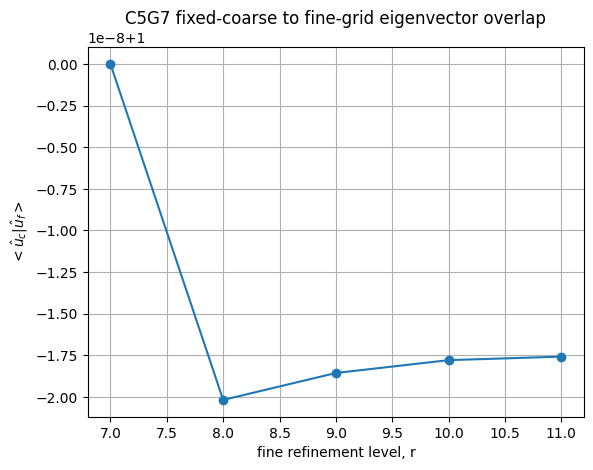

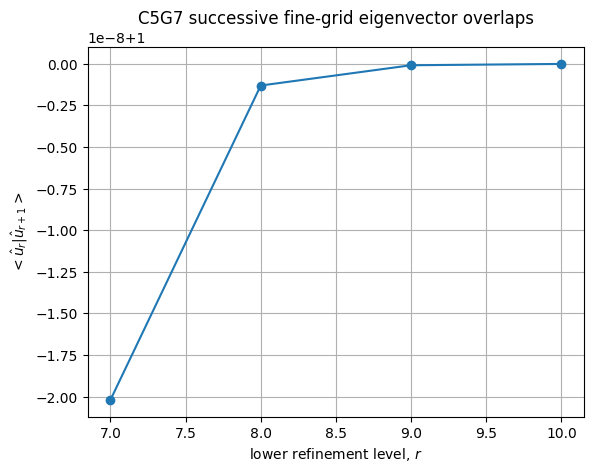

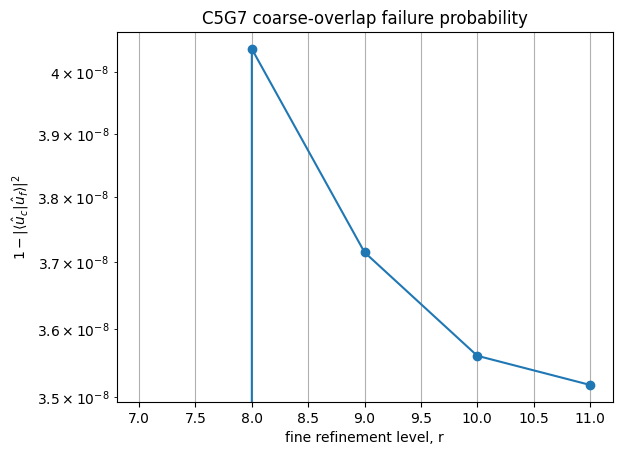

In [15]:
min_r = 7  # minimum refinement level for the fine solutions
max_r = 11  # maximum refinement level for the fine solutions
coarse_r = 7  # fixed coarse reference level

fine_sol_overlaps, successive_fine_overlaps = get_fine_overlaps(
    min_r=min_r,
    max_refinement=max_r,
    coarse_refinement=coarse_r,
)

# Plot the overlap of the fixed coarse solution with each fine solution.
plt.plot(
    range(min_r, max_r + 1),
    fine_sol_overlaps,
    marker="o",
)
plt.xlabel("fine refinement level, r")
plt.ylabel(r'$< \hat{u}_c | \hat{u}_f>$')
plt.title("C5G7 fixed-coarse to fine-grid eigenvector overlap")
plt.grid(True)
plt.show()

# The point at r compares the fine solutions at levels r and r + 1.
plt.plot(
    range(min_r, max_r),
    successive_fine_overlaps,
    marker="o",
)
plt.xlabel(r"lower refinement level, $r$")
plt.ylabel(r'$< \hat{u}_r | \hat{u}_{r+1}>$')
plt.title("C5G7 successive fine-grid eigenvector overlaps")
plt.grid(True)
plt.show()

# Plot the failure probability implied by the coarse overlap.
plt.semilogy(
    range(min_r, max_r + 1),
    1 - np.square(fine_sol_overlaps),
    marker="o",
)
plt.xlabel("fine refinement level, r")
plt.ylabel(r'$1 - |\langle \hat{u}_c | \hat{u}_f \rangle|^2$')
plt.title("C5G7 coarse-overlap failure probability")
plt.grid(True)
plt.show()


In [5]:
# Compare a uniform interior state with C5G7 fine-grid eigenvectors.
def get_uniform_superposition_overlaps(
    min_r,
    max_refinement,
    data_directory=None,
    apply_b_sqrt=True
):
    if min_r > max_refinement:
        raise ValueError("min_r must not exceed max_refinement.")

    total_mat, sigma_a_mat, nu_sigma_f_mat = (
        load_and_collapse_c5g7_full_core(data_directory)
    )
    if np.any(total_mat <= 0.0):
        raise ValueError("The collapsed total cross section must be positive.")
    D_mat = 1.0 / (3.0 * total_mat)
    mat_r = 7  # 2**7 cells per axis matches the padded material arrays.

    uniform_overlaps = []
    successive_fine_overlaps = []
    eigenvector_l2_errors = []
    previous_fine_solution = None
    previous_r = None

    for r in range(min_r, max_refinement + 1):
        eigenvalue, fine_solution = eigvecs_at_level_defined(
            mat_r=mat_r,
            r=r,
            D_mat=D_mat,
            sigma_a_mat=sigma_a_mat,
            nu_sigma_f_mat=nu_sigma_f_mat,
            do_plot=False,
            apply_b_sqrt=apply_b_sqrt
        )
        fine_solution = fix_sign(fine_solution)
        fine_points_per_axis = 2**r + 1
        fine_grid = np.linspace(0.0, 1.0, fine_points_per_axis)
        fine_x, fine_y = np.meshgrid(
            fine_grid, fine_grid, indexing="ij"
        )
        fine_points = np.column_stack((fine_x.ravel(), fine_y.ravel()))
        interior_mask = (
            (fine_points[:, 0] > 0.0)
            & (fine_points[:, 0] < 1.0)
            & (fine_points[:, 1] > 0.0)
            & (fine_points[:, 1] < 1.0)
        )
        fine_interior = fine_solution[interior_mask]
        fine_interior_normalized = (
            fine_interior / np.linalg.norm(fine_interior)
        )

        if previous_fine_solution is not None:
            previous_points_per_axis = 2**previous_r + 1
            previous_grid = np.linspace(
                0.0, 1.0, previous_points_per_axis
            )
            previous_interpolator = RegularGridInterpolator(
                (previous_grid, previous_grid),
                previous_fine_solution.reshape(
                    (previous_points_per_axis, previous_points_per_axis)
                ),
                method="linear",
            )
            previous_interior = previous_interpolator(fine_points)[
                interior_mask
            ]
            previous_interior /= np.linalg.norm(previous_interior)
            successive_fine_overlaps.append(
                float(abs(np.dot(
                    previous_interior, fine_interior_normalized
                )))
            )

        # Integrate the absolute value of the continuous Q1 FEM function.
        # Boundary coefficients in fine_solution are already zero due
        # to the homogeneous Dirichlet boundary condition.
        _, _, fine_basis = _tensor_product_basis(
            r, dim=2, intorder=4
        )
        fine_field = fine_basis.interpolate(fine_solution)
        fine_l1_norm = float(np.sum(np.abs(fine_field.value) * fine_basis.dx))
        fine_l2_norm = float(np.sqrt(np.sum(
            np.abs(fine_field.value) ** 2 * fine_basis.dx
        )))

        uniform_interior = np.ones_like(fine_interior_normalized)
        uniform_interior /= np.linalg.norm(uniform_interior)
        eigenvector_l2_errors.append(
            float(np.linalg.norm(
                uniform_interior - fine_interior_normalized
            ))
        )
        uniform_overlaps.append(
            float(abs(np.dot(
                uniform_interior, fine_interior_normalized
            )))
        )
        previous_fine_solution = fine_solution.copy()
        previous_r = r
        print(
            f"level: {r}, lambda1: {eigenvalue}, "
            f"full_size: {len(fine_solution)}"
        )

    print("Refinement values = ", list(range(min_r, max_refinement + 1)))
    print(r"|| \hat{u}_{uniform} - \hat{u}_f ||  = ", eigenvector_l2_errors)
    print(r"< \hat{u}_{uniform} | \hat{u}_f>  = ", uniform_overlaps)
    print(
        r"< \hat{u}_r | \hat{u}_{r+1}>  = ",
        successive_fine_overlaps,
    )
    return uniform_overlaps, successive_fine_overlaps, fine_l1_norm, fine_l2_norm

# Run the C5G7 uniform-superposition overlap test

In [14]:
min_r = 5  # minimum refinement level for the fine solutions
max_r = 11  # maximum refinement level for the fine solutions

uniform_overlaps, successive_uniform_fine_overlaps, fine_l1_norm_list, fine_l2_norm_list = (
    get_uniform_superposition_overlaps(
        min_r=min_r,
        max_refinement=max_r,
        apply_b_sqrt=True
    )
)

print("uniform_overlaps = ", uniform_overlaps)
print("successive_uniform_fine_overlaps = ", successive_uniform_fine_overlaps)
print("fine_l1_norm_list = ", fine_l1_norm_list)
print("fine_l2_norm_list = ", fine_l2_norm_list)



level: 5, lambda1: 90.15969549812039, full_size: 1089
level: 6, lambda1: 87.57156366346535, full_size: 4225
level: 7, lambda1: 87.48856619565724, full_size: 16641
level: 8, lambda1: 87.4698620513959, full_size: 66049
level: 9, lambda1: 87.46502747769432, full_size: 263169
level: 10, lambda1: 87.46376410521323, full_size: 1050625
level: 11, lambda1: 87.46343424467133, full_size: 4198401
Refinement values =  [5, 6, 7, 8, 9, 10, 11]
|| \hat{u}_{uniform} - \hat{u}_f ||  =  [0.9467812146752209, 0.9590791361311498, 0.9695190394118378, 0.980961218769339, 0.9893573549763531, 0.9942632230368473, 0.9968878902170301]
< \hat{u}_{uniform} | \hat{u}_f>  =  [0.5518026657690567, 0.5400836053189637, 0.5300164161089734, 0.5188575436352868, 0.5105860120770981, 0.5057203216581946, 0.5031072671693505]
< \hat{u}_r | \hat{u}_{r+1}>  =  [0.9910408179862434, 0.9956043314546635, 0.9864453345325235, 0.9927170595449808, 0.9961236181422777, 0.9980084791993138]
uniform_overlaps =  [0.5518026657690567, 0.54008360531

# Cached C5G7 results

In [17]:
min_r = 7  # minimum refinement level for the fine solutions
max_r = 11  # maximum refinement level for the fine solutions

uniform_overlaps =  [0.5300164161089734, 0.5188575436352868, 0.5105860120770981, 0.5057203216581946, 0.5031072671693505]
successive_uniform_fine_overlaps =  [0.9864453345325235, 0.9927170595449808, 0.9961236181422777, 0.9980084791993138]
fine_l1_norm_list =  0.00024553795174251395
fine_l2_norm_list =  0.00048765110035217126

# plot the C5G7 Uniform Superposition results

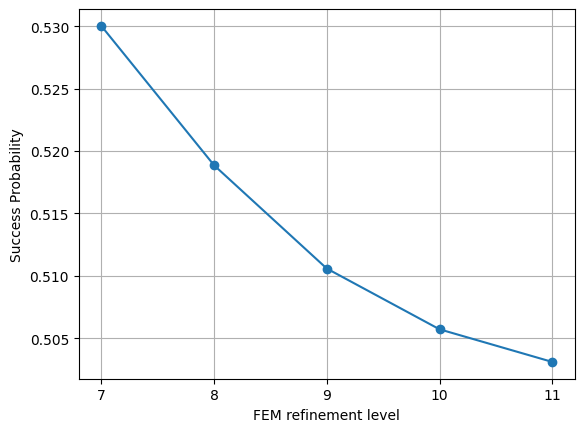

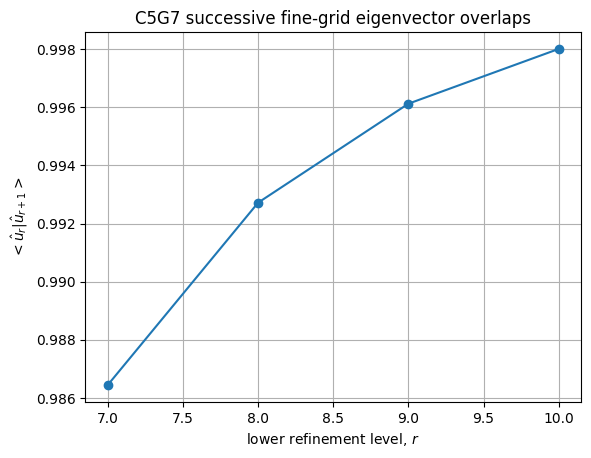

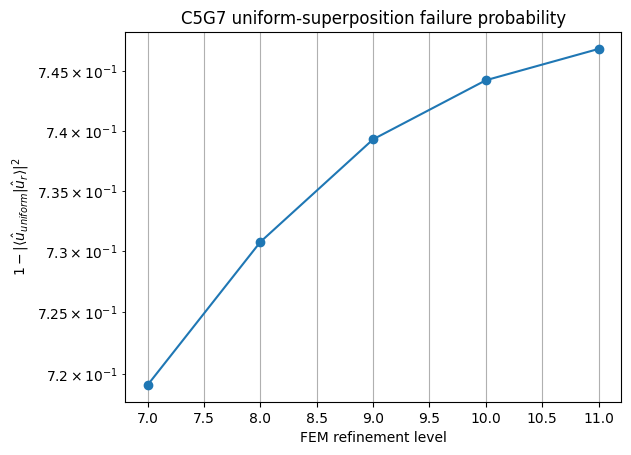

In [19]:
# plot the expected asymptote
'''ratio = fine_l1_norm / fine_l2_norm
line, = plt.plot(
    list(range(min_r, max_r+1)),
    uniform_overlaps,
)
plt.axhline(
    ratio,
    color=line.get_color(),
    linestyle="--",
)'''

# Plot the overlap of the uniform state with each C5G7 eigenvector.
plt.plot(
    range(min_r, max_r + 1),
    uniform_overlaps,
    marker="o",
)
plt.xlabel("FEM refinement level")
#plt.ylabel(r'$< \hat{u}_{uniform} | \hat{u}_r>$')
plt.ylabel("Success Probability")
plt.xticks(range(min_r, max_r+1))
plt.grid(True)
plt.show()

# The point at r compares the fine solutions at levels r and r + 1.
plt.plot(
    range(min_r, max_r),
    successive_uniform_fine_overlaps,
    marker="o",
)
plt.xlabel(r"lower refinement level, $r$")
plt.ylabel(r'$< \hat{u}_r | \hat{u}_{r+1}>$')
plt.title("C5G7 successive fine-grid eigenvector overlaps")
plt.grid(True)
plt.show()

# Plot the failure probability for the uniform state.
plt.semilogy(
    range(min_r, max_r + 1),
    1 - np.square(uniform_overlaps),
    marker="o",
)
plt.xlabel("FEM refinement level")
plt.ylabel(r'$1 - |\langle \hat{u}_{uniform} | \hat{u}_r \rangle|^2$')
plt.title("C5G7 uniform-superposition failure probability")
plt.grid(True)
plt.show()
